In [2]:
import requests
from IPython.core.display import HTML
# HTML(f"""
# <style>
# @import "https://cdn.jsdelivr.net/npm/bulma@0.9.4/css/bulma.min.css";
# </style>
# """)

### Q1 Exercises Week 2-3 (Vector & Matrices)

#### (a) Focus on inner products, vector operations, distance metrics and their relation to ML (evaluation and other metrics). You may relate this to week 10 (evaluation) but focus on vectors.
- inner products
- vector operations
    - addition/subtraction/scaling
- distance metrics
    - Euclidean distance (square root of dot )
    - Example of use: similarity between poses
    - Alternative: cosine similarity (in week 11.04, comparing faces based on HoG features)

#### (b) Focus on matrices and their operations (addition, multiplication, transpose, inverse, determinant, orthogonal). Relate them to their application within the course (e.g., transformations, basis in week 11).
- matrix operations (see W03 0x)
    - addition
    - scalar multiplication (relation to scaling of vectors)
    - matrix multiplication (relation to linear transformations)
    - transpose (flips and relation to inner products)
    - inverse (undoing transformations)
    - determinant (area scaling and invertibility)
    - orthogonal (relation to orthonormal bases and rotations)
    (for all above, also include relation to applications within the course)
- Bases and transformations (week 11.05)

#### (c) Focus on how linear equations and their solutions are related to matrices.
- linear systems 
- solving linear systems using matrix methods (using matrix multiplication, determinant and inverse)
- relation to fitting models to data (finding weights that minimize error between predictions and actual labels)

# Evaluating poses
<article class="message is-info">
  <div class="message-header">Overview</div>
  <div class="message-body">
  
  In this exercise you will compare high-dimensional vectors of human poses (from a dataset of badminton poses) using distance between poses. The dataset contains 18 sample poses, each defined by 25 points $(x_i, y_i)$. Your task is to calculate the Euclidean distance ($L_2$-norm) between all poses.
    </div>
</article>
  

<article class="message">
    <div class="message-body">
        <strong>Overview of tasks</strong>
        <ul style="list-style: none;">
            <li>
            <a href="#load">Task 1: Load and inspect the data</a>
            </li>
            <li>
            <a href="#inspect">Task 2: Visually inspect and compare poses</a>
            </li>
            <li>
            <a href="#dist">Task 3: Calculate pose distance</a>
            </li>
            <li>
            <a href="#comparison">Task 4: Most similar pose pairs</a>
            </li>
            <li>
            <a href="#comparison2">Task 5: Compare poses</a>
            </li>
        </ul>
    </div>
</article>

The dataset is loaded and stored in an $18\times 50$-dimensional Numpy array. Each row in `poses`
 has the form $x_1, y_1, x_2, y_2, \dots, x_{25}, y_{25}$, i.e. it is a list of $50$ elements constituting $25$ points.
<article class="message task"><a class="anchor" id="load"></a>
    <div class="message-header">
        <span>Task 1: Load and inspect the data</span>
        <span class="has-text-right">
          <i class="bi bi-lightbulb-fill"></i>
          <i class="bi bi-stoplights easy"></i>
        </span>
    </div>
<div class="message-body">


1. Run the cell below to load the data.
2. Print the first pose in the dataset (index 0).

**Note:** Note that the output above is still a 1D array, it is simply printed over multiple lines



</div></article>



In [3]:
import numpy as np
import matplotlib.pyplot as plt
import util_poses

poses = np.load("data/poses.npy")

In [4]:
# Get the first pose and print it
# Write your solution here
print(poses[0])

[-27.99571178  -6.48683038  -0.11660905  -1.17064333   0.84333174
  -1.17055863   1.40324612  -0.75536782   1.64424262  -0.39685233
  -0.91658014  -1.19784466  -1.47706657  -0.75565014  -1.63809865
  -0.67290277  -0.0346016   -0.2573026    0.52441385  -0.28487094
   0.92472628   0.2406497    1.08637127   0.87586495  -0.35960773
  -0.2296778   -0.75350502   0.46266449  -0.75767282   1.26336037
 -27.99571178  -6.48683038 -27.99571178  -6.48683038   0.4412623
  -1.52924351  -0.43720223  -1.53048571  -1.23831741   1.26319098
  -1.39460965   1.34502082  -0.67480729   1.34740641   0.68458786
   1.12472817   1.08424651   1.09708925   1.16224962   0.93142511]


The cell below visualises each pose in the dataset:


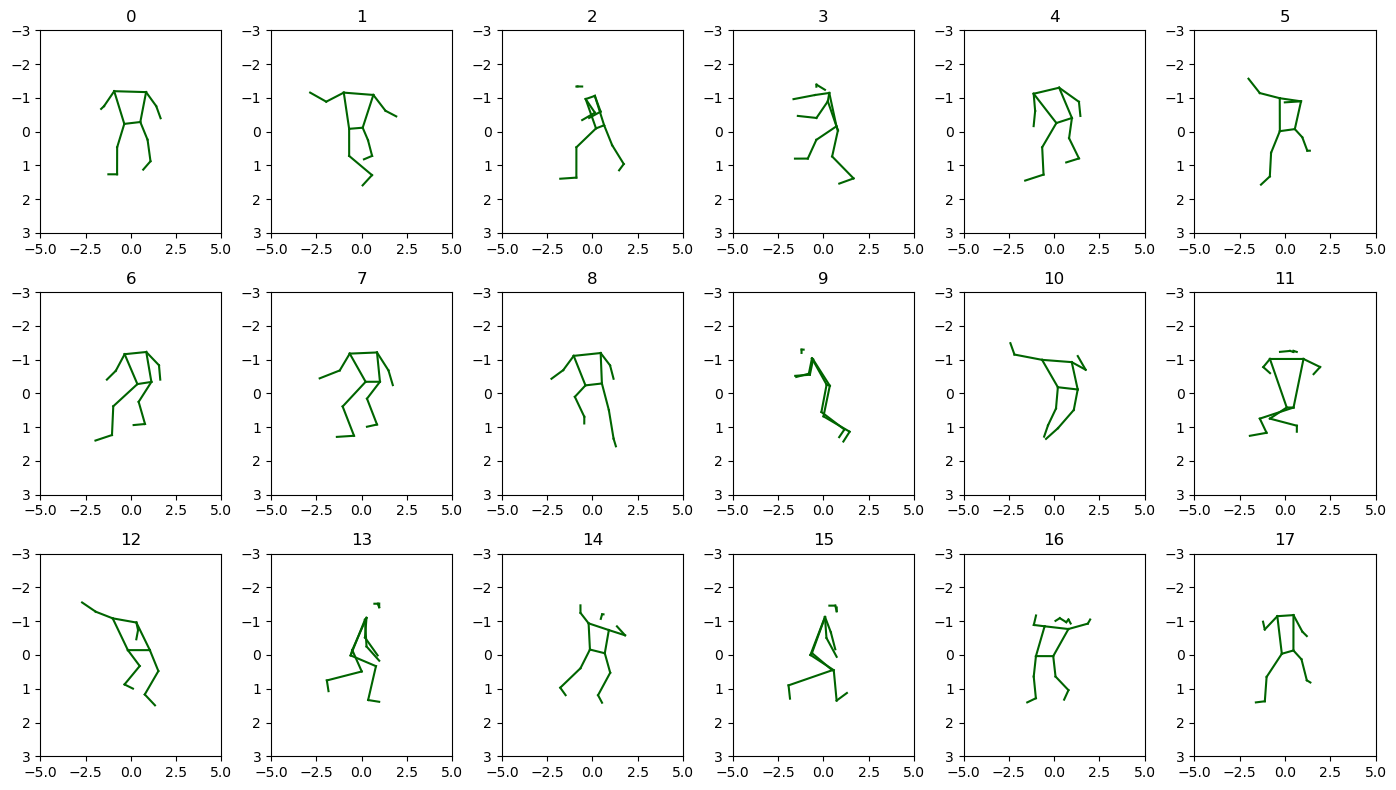

In [5]:
# Create a 6x3 grid of subplots
fig, ax = plt.subplots(3, 6, figsize=(14, 8))

for i, p in enumerate(poses):
    axis = ax[i//6, i%6] # Select the appropriate subplot
    util_poses.plot_single_pose(p, axis)

    axis.set_title(i)
    axis.set_xlim(-5, 5)
    axis.set_ylim(3,-3)


plt.tight_layout()

<article class="message task"><a class="anchor" id="inspect"></a>
    <div class="message-header">
        <span>Task 2: Visually inspect and compare poses</span>
        <span class="has-text-right">
          <i class="bi bi-lightbulb-fill"></i>
          <i class="bi bi-stoplights easy"></i>
        </span>
    </div>
<div class="message-body">


This task involves visual inspection of the poses.
1. Choose the three pairs of poses that look most similar and note their indices.
2. Choose the three pairs of poses that look least similar and note their indices.



</div></article>



# Note the indices of the poses here.
1. 
most similar: 4, 6, 7
- 4, 6
- 6, 7
- 13,15
least similar: 5, 8, 13
- 8, 13
- 2, 12
- 9, 11

<article class="message task"><a class="anchor" id="dist"></a>
    <div class="message-header">
        <span>Task 3: Calculate pose distance</span>
        <span class="has-text-right">
          <i class="bi bi-code"></i>
          <i class="bi bi-file-ppt" style="color: blue;"></i>
          <i class="bi bi-stoplights easy"></i>
        </span>
    </div>
<div class="message-body">


In this task you will calculate the Euclidean distance ($L_2$ norm) between all the poses.
**Note:** Note that the distance is symmetric, such that the distance between pairs (a, b) and (b, a) are the same.

1. In the cell below, calculate the Euclidean distance between each combination of poses and store the result in an $18\times 18$ matrix called `res`
 (the name is important as the variable is used below) such that the distance between `poses[i]`
 and `poses[j]`
 is in position $i, j$ in the matrix.



</div></article>



In [6]:
# Write your solution here
def length(v):
    return np.sum(v**(2))**(1/2)

def euclidean_dist(a,b):
    return length(a-b)

res = [[(euclidean_dist(i, j)) for i in poses] for j in poses]

The following cell creates an 18x18 distance matrix: 


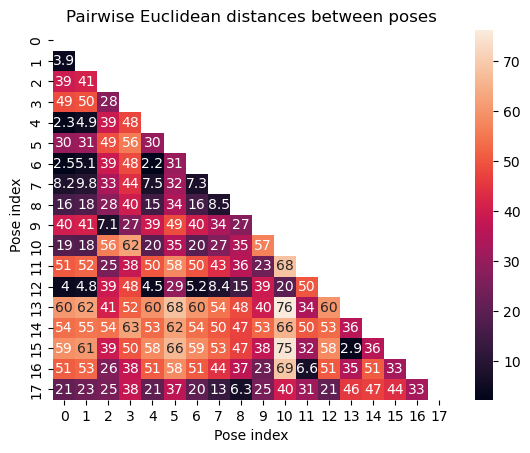

In [20]:
import seaborn as sns
t = np.triu(np.ones_like(res))
sns.heatmap(res, annot=True, mask=t)
plt.title("Pairwise Euclidean distances between poses")
plt.xlabel("Pose index")
plt.ylabel("Pose index")
plt.show()

<article class="message task"><a class="anchor" id="comparison"></a>
    <div class="message-header">
        <span>Task 4: Most similar pose pairs</span>
        <span class="has-text-right">
          <i class="bi bi-code"></i>
          <i class="bi bi-stoplights medium"></i>
        </span>
    </div>
<div class="message-body">


The **mandatory** part of the exercise has to be entered in [Grasple](https://app.grasple.com/#/courses/10532/ci/733917/diagnoses/12885)
 and requires you to complete question 1.
1. Determine the three most similar pose-pairs using the distances calculated in the distance matrix `res`
 and plot them using the plotting function `plot_pair`
 from the file `util_poses.py`
. The function input is two full pose rows, hence input as e.g `poses[x], poses[y]`
 where `x`
 and `y`
 are indices.
2. Determine the three most dissimilar pose-pairs using the distances calculated in the distance matrix `res`
 and plot them.



</div></article>



most similar pairs of poses (smallest distance):
[(6, 4), (4, 0), (6, 0)]
least similar pairs of poses (largest distance):
[(13, 10), (15, 10), (16, 10)]

Most similar pairs of poses (smallest distance):
1. Pose 6 and 4 with distance 2.21:


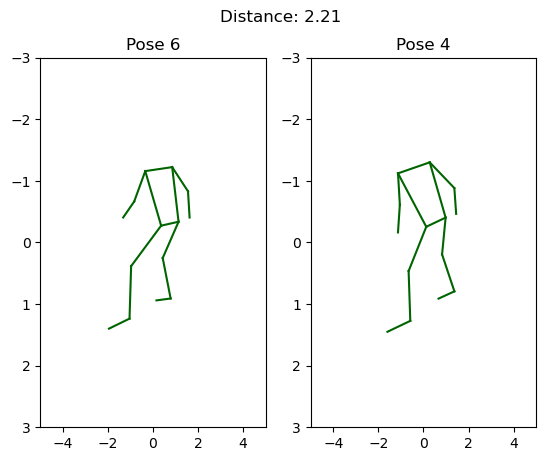

2. Pose 4 and 0 with distance 2.30:


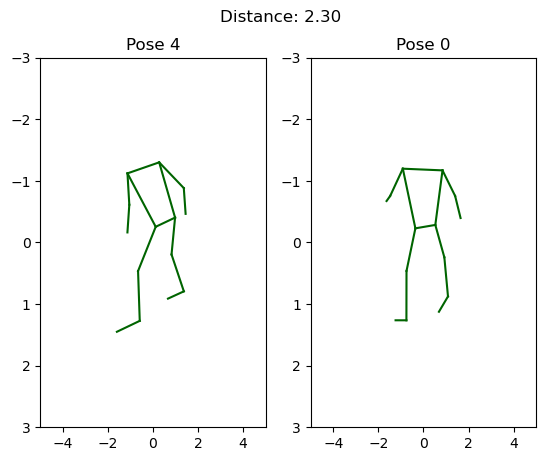

3. Pose 6 and 0 with distance 2.50:


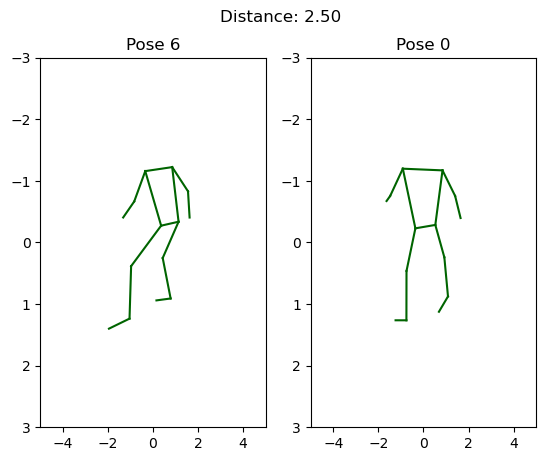


Least similar pairs of poses (largest distance):
1. Pose 13 and 10 with distance 76.25:


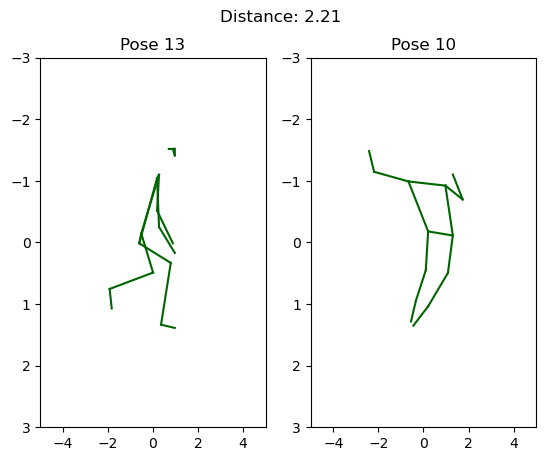

2. Pose 15 and 10 with distance 74.95:


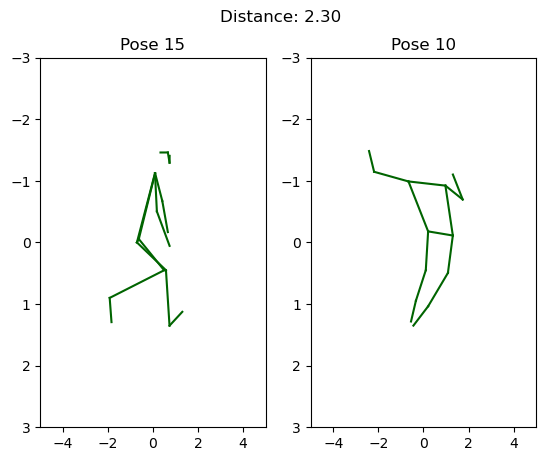

3. Pose 16 and 10 with distance 68.83:


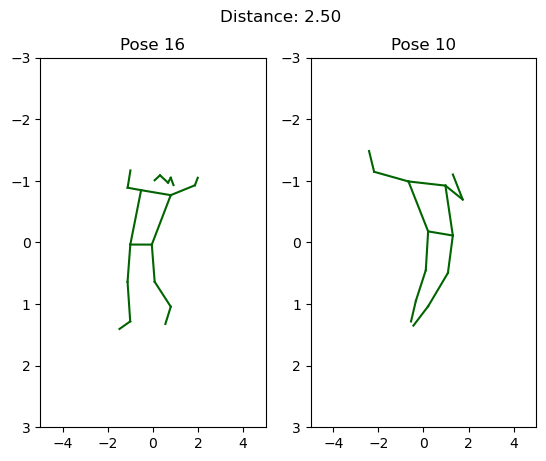

In [17]:
# Write your solution here
# In the heatmap, the smallest distances (most similar poses) are represented by the darkest colors, 
# while the largest distances (least similar poses) are represented by the lightest colors.
# We can identify the most and least similar pairs of poses based on the colors. 
# Additionally, we can also compare the exact numerical distances to confirm our observations.

#Most similar pairs of poses (smallest distance):
# 1. (6,4) 
# 2. (4,0) 
# 3. (6,0)

#Least similar pairs of poses (largest distance):
# 1. (10,13)
# 2. (10,15)
# 3. (10,16)

# Calculations to determine the most and least similar pairs of poses mathematically:
res = np.array(res)

min_distance = [float('inf'), float('inf'), float('inf')]
max_distance = [float('-inf'), float('-inf'), float('-inf')]
most_similar_pair = [None, None, None]
least_similar_pair = [None, None, None]

for i in range(len(res)):
    for j in range(len(res[i])):
        if j < i:
            for k in range(3):
                if res[i][j] < min_distance[k]:
                    for l in range (3-k):
                        min_distance[2-l] = min_distance[2-l-1]
                        most_similar_pair[2-l] = most_similar_pair[2-l-1]
                    min_distance[k] = res[i][j]
                    most_similar_pair[k] = (i, j)
                    break
                if res[i][j] > max_distance[k]:
                    for l in range (3-k):
                        max_distance[2-l] = max_distance[2-l-1]
                        least_similar_pair[2-l] = least_similar_pair[2-l-1]
                    max_distance[k] = res[i][j]
                    least_similar_pair[k] = (i, j)
                    break

print("most similar pairs of poses (smallest distance):")
print(most_similar_pair)
print("least similar pairs of poses (largest distance):")
print(least_similar_pair)

#Plot:
import util_poses

print("\nMost similar pairs of poses (smallest distance):")
for i, p in enumerate(most_similar_pair):
    print(f"{i+1}. Pose {p[0]} and {p[1]} with distance {min_distance[i]:.2f}:")
    util_poses.plot_pair(poses[p[0]], poses[p[1]])
    plt.suptitle(f"Distance: {min_distance[i]:.2f}")
    plt.subplot(1, 2, 1)
    plt.title(f"Pose {p[0]}")
    plt.subplot(1, 2, 2)
    plt.title(f"Pose {p[1]}")
    plt.show()

print("\nLeast similar pairs of poses (largest distance):")
for i, p in enumerate(least_similar_pair):
    print(f"{i+1}. Pose {p[0]} and {p[1]} with distance {max_distance[i]:.2f}:")
    util_poses.plot_pair(poses[p[0]], poses[p[1]])
    plt.suptitle(f"Distance: {min_distance[i]:.2f}")
    plt.subplot(1, 2, 1)
    plt.title(f"Pose {p[0]}")
    plt.subplot(1, 2, 2)
    plt.title(f"Pose {p[1]}")
    plt.show()
    

<article class="message task"><a class="anchor" id="comparison2"></a>
    <div class="message-header">
        <span>Task 5: Compare poses</span>
        <span class="has-text-right">
          <i class="bi bi-lightbulb-fill"></i>
          <i class="bi bi-file-ppt" style="color: blue;"></i>
          <i class="bi bi-stoplights medium"></i>
        </span>
    </div>
<div class="message-body">


1. Compare the pose-pairs you chose in [Task 2](#inspect) with the calculated pose-pairs. How well did your intuition match the calculated result?



</div></article>



In [9]:
# write your reflections here
# Intuitive results:
#most similar: 
#- 4, 6
#- 6, 7
#- 13,15
#least similar: 
#- 8, 13
#- 2, 12
#- 9, 11

# Calculated results:
#most similar:
#- 6, 4
#- 0, 4
#- 0, 6
#least similar:
#- 10, 16
#- 10, 15
#- 10, 13

# I only got one pair correct (6,4) in the most similar category and none in the least similar category.
# It was very difficult to judge which poses were more or less similar just by looking at them.
# Especially identifying the least similar pairs was challenging.
# I was considering a lot of different pose-pairs in task 2 as being the least similar, 
# but I don't think I would have ever picked the the calculated one (10, 16), 
# and i think that is because we as humans add value to the poses other than just seeing them as lines.
